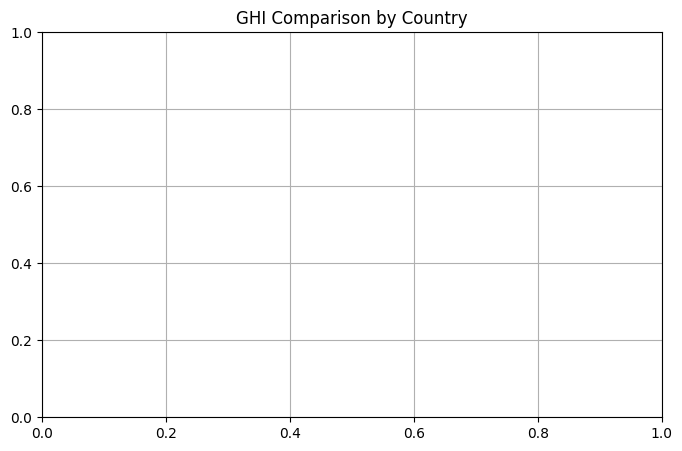

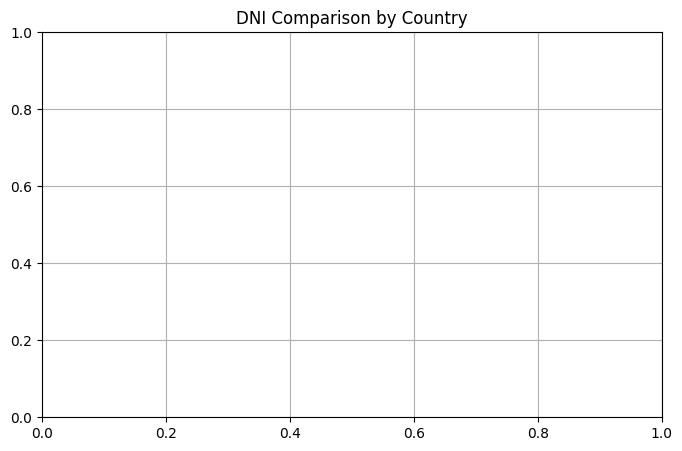

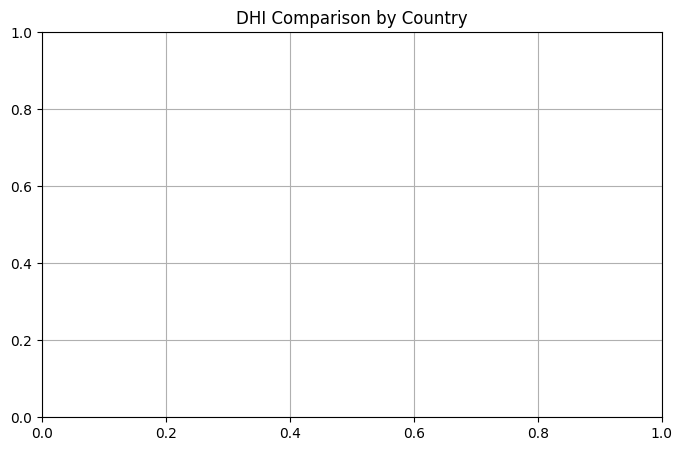

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal


# Load datasets
benin = pd.read_csv('data/benin_clean.csv')
sierra_leone = pd.read_csv('data/sierraleon_clean.csv')
togo = pd.read_csv('data/togo_clean.csv')

# Add country column
benin['Country'] = 'Benin'
sierra_leone['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'

# Combine
df_all = pd.concat([benin, sierra_leone, togo], ignore_index=True)

metrics = ['GHI', 'DNI', 'DHI']

for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Country', y=metric, data=df_all)
    plt.title(f'{metric} Comparison by Country')
    plt.grid(True)
    plt.show()




In [20]:
summary = df_all.groupby('Country')[['GHI', 'DNI', 'DHI']].agg(['mean', 'median', 'std'])
summary

Empty DataFrame
Columns: [(GHI, mean), (GHI, median), (GHI, std), (DNI, mean), (DNI, median), (DNI, std), (DHI, mean), (DHI, median), (DHI, std)]
Index: []

In [ ]:
# ANOVA for GHI
f_stat, p_val = f_oneway(
    benin['GHI'].dropna(),
    sierra_leone['GHI'].dropna(),
    togo['GHI'].dropna()
)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val:.4e}")


# Optional: Kruskal–Wallis
h_stat, p_kw = kruskal(
    benin['GHI'].dropna(),
    sierra_leone['GHI'].dropna(),
    togo['GHI'].dropna()
)

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}, p-value: {p_kw:.4e}")
